**Use of AI Assistance — AI Acknowledgement**

For this assignment, I used Claude to help structure the Python code for computing SHAP values, running LIME explanations, and generating DiCE counterfactuals. The AI helped me understand how each method works and how to correctly set up the explainers in Google Colab. I also used AI to support parts of my coding process to make sure there were no errors. When errors came up during testing, I used the AI to help me understand what the mistake was, why it occurred, and how to correct it.

**Task 1: SHAP Values**

In [1]:
!pip install shap lime dice-ml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load and filter data (same as before)
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

df = raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text',
               'sex', 'priors_count', 'days_b_screening_arrest',
               'decile_score', 'is_recid', 'two_year_recid',
               'c_jail_in', 'c_jail_out']].copy()

df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df['score_factor_bin'] = (df['score_text'] != 'Low').astype(int)

# Encode categorical features
le = {}
for col in ['c_charge_degree', 'race', 'sex', 'age_cat']:
    le[col] = LabelEncoder()
    df[col + '_enc'] = le[col].fit_transform(df[col])

feature_names = ['age', 'priors_count', 'two_year_recid',
                 'c_charge_degree', 'race', 'sex', 'age_cat']
X_cols = ['age', 'priors_count', 'two_year_recid',
          'c_charge_degree_enc', 'race_enc', 'sex_enc', 'age_cat_enc']

X = df[X_cols].values
y = df['score_factor_bin'].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42)

# Train COMPAS replacement model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
print(f"Model accuracy: {clf.score(X_test, y_test):.3f}")

Model accuracy: 0.747


In [4]:
idx_test_list = list(idx_test)
df_test       = df.loc[idx_test].copy()
df_test['pred_prob'] = clf.predict_proba(X_test)[:, 1]

black_test = df_test[df_test['race'] == 'African-American']
white_test = df_test[df_test['race'] == 'Caucasian']

black_high_idx = black_test['pred_prob'].idxmax()
black_low_idx  = black_test['pred_prob'].idxmin()
white_high_idx = white_test['pred_prob'].idxmax()
white_low_idx  = white_test['pred_prob'].idxmin()

four_ids = {
    'Black — Highest Risk': black_high_idx,
    'Black — Lowest Risk':  black_low_idx,
    'White — Highest Risk': white_high_idx,
    'White — Lowest Risk':  white_low_idx
}

print("Four individuals selected:\n")
for label, idx in four_ids.items():
    prob = df_test.loc[idx, 'pred_prob']
    race = df_test.loc[idx, 'race']
    print(f"  {label}: predicted probability = {prob:.3f}")

Four individuals selected:

  Black — Highest Risk: predicted probability = 1.000
  Black — Lowest Risk: predicted probability = 0.038
  White — Highest Risk: predicted probability = 0.999
  White — Lowest Risk: predicted probability = 0.006


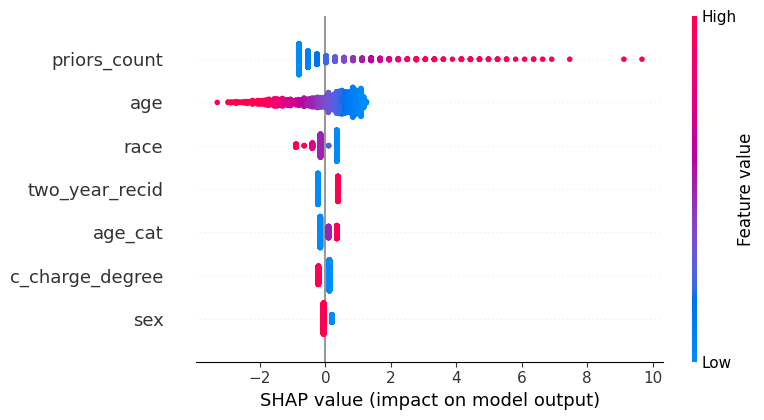

In [5]:
explainer  = shap.LinearExplainer(clf, X_train,
                                   feature_perturbation="interventional")
shap_vals  = explainer.shap_values(X_test)

shap.summary_plot(shap_vals, X_test, feature_names=feature_names,
                  plot_type="dot", show=True)


── Black — Highest Risk ──────────────────────────────────────────


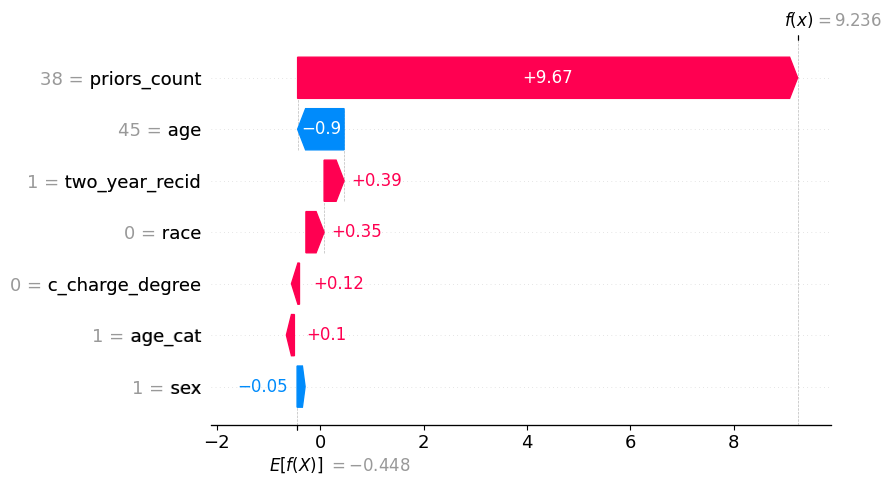


── Black — Lowest Risk ──────────────────────────────────────────


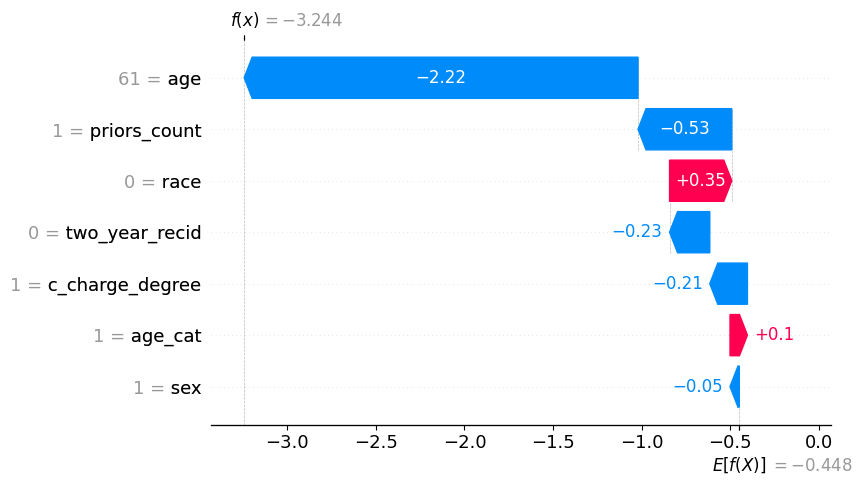


── White — Highest Risk ──────────────────────────────────────────


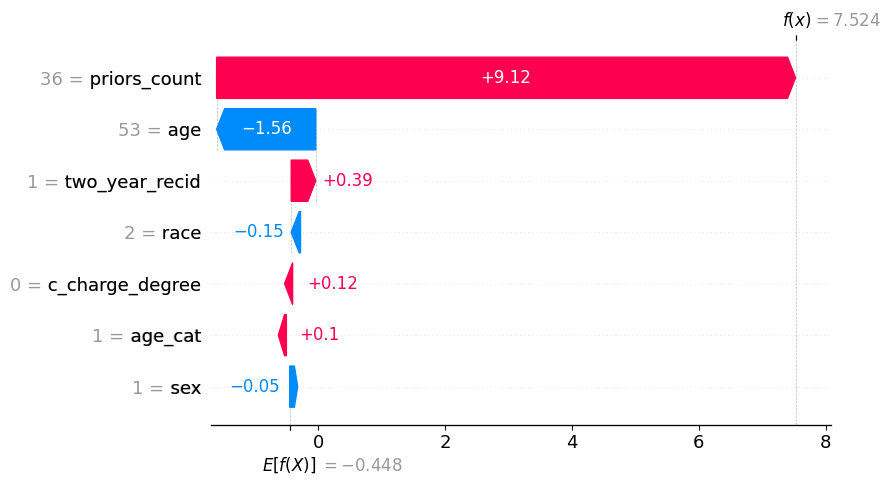


── White — Lowest Risk ──────────────────────────────────────────


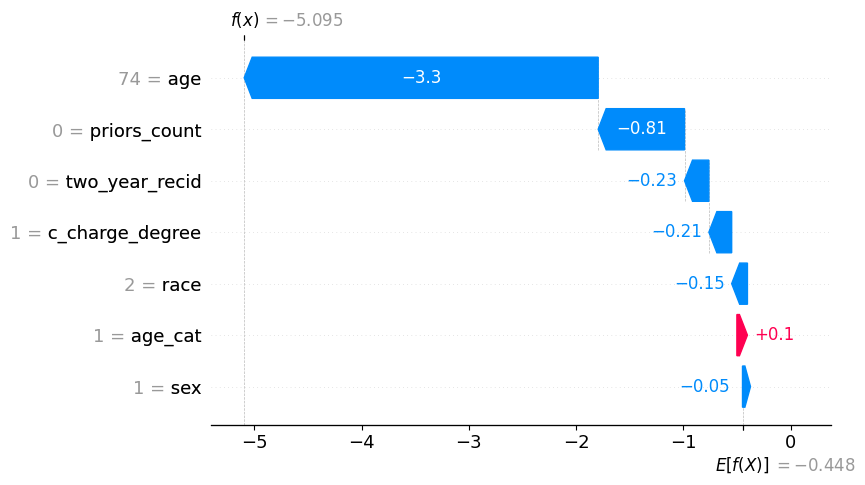

In [6]:
for label, idx in four_ids.items():
    pos = idx_test_list.index(idx)
    exp = shap.Explanation(
        values        = shap_vals[pos],
        base_values   = explainer.expected_value,
        data          = X_test[pos],
        feature_names = feature_names
    )
    print(f"\n── {label} ──────────────────────────────────────────")
    shap.plots.waterfall(exp)

**Task 2 - Lime**


── LIME: Black — Highest Risk ──────────────────────────────
  priors_count > 4.00                            +0.4434
  age > 42.00                                    -0.3202
  race <= 0.00                                   +0.1020
  0.00 < two_year_recid <= 1.00                  +0.0999
  c_charge_degree <= 0.00                        +0.0582
  0.00 < age_cat <= 1.00                         +0.0164
  sex <= 1.00                                    +0.0000


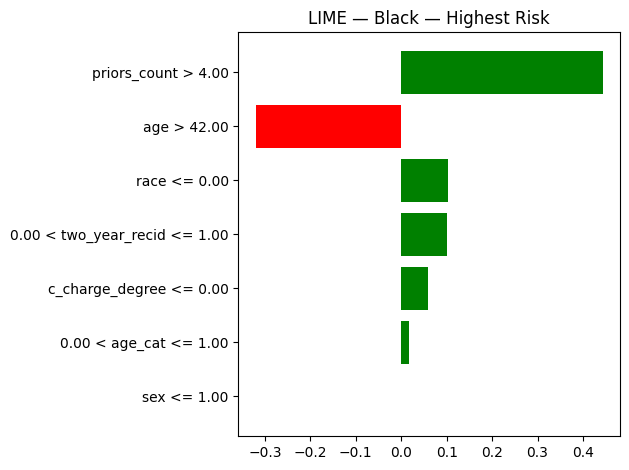


── LIME: Black — Lowest Risk ──────────────────────────────
  age > 42.00                                    -0.3110
  0.00 < priors_count <= 1.00                    -0.1423
  race <= 0.00                                   +0.1081
  two_year_recid <= 0.00                         -0.1011
  0.00 < c_charge_degree <= 1.00                 -0.0563
  0.00 < age_cat <= 1.00                         +0.0150
  sex <= 1.00                                    +0.0000


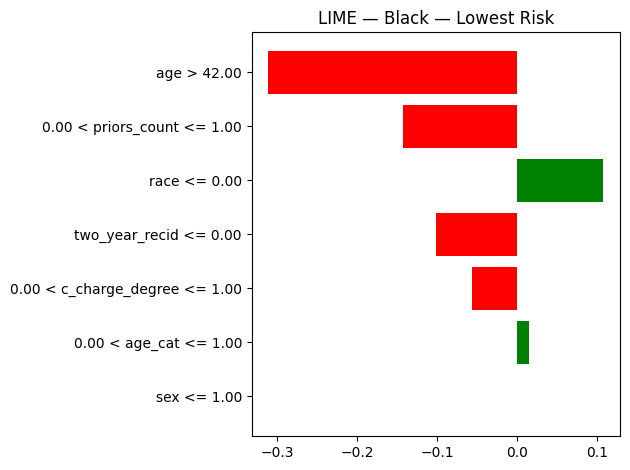


── LIME: White — Highest Risk ──────────────────────────────
  priors_count > 4.00                            +0.4496
  age > 42.00                                    -0.3138
  0.00 < two_year_recid <= 1.00                  +0.0990
  c_charge_degree <= 0.00                        +0.0539
  0.00 < race <= 2.00                            -0.0528
  0.00 < age_cat <= 1.00                         +0.0104
  sex <= 1.00                                    +0.0000


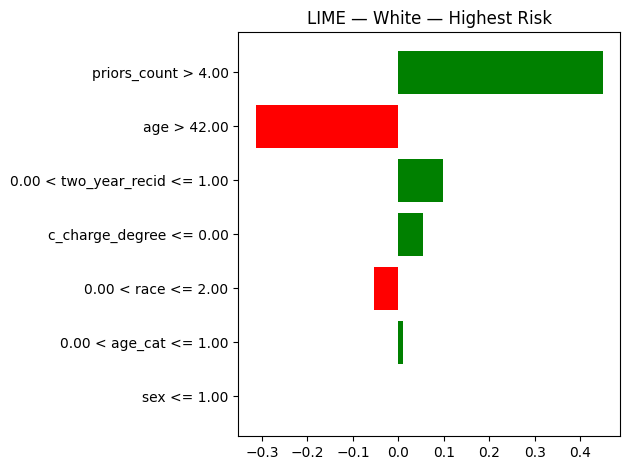


── LIME: White — Lowest Risk ──────────────────────────────
  age > 42.00                                    -0.2991
  priors_count <= 0.00                           -0.2380
  two_year_recid <= 0.00                         -0.0963
  0.00 < c_charge_degree <= 1.00                 -0.0568
  0.00 < race <= 2.00                            -0.0401
  0.00 < age_cat <= 1.00                         +0.0358
  sex <= 1.00                                    +0.0000


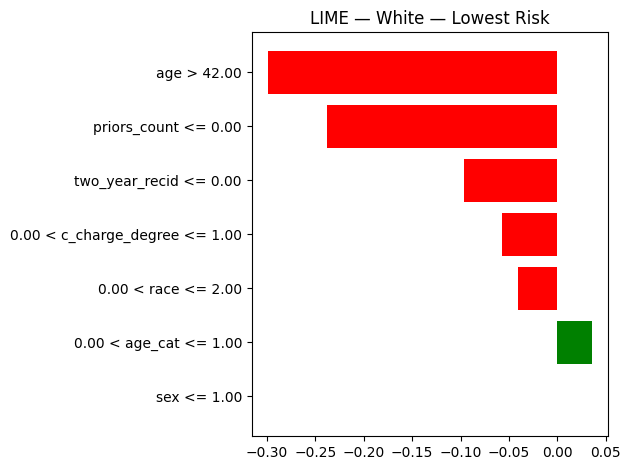

In [7]:
import lime
import lime.lime_tabular

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=['Low Score', 'High Score'],
    mode='classification',
    random_state=42
)

lime_results = {}
for label, idx in four_ids.items():
    pos       = idx_test_list.index(idx)
    instance  = X_test[pos]
    exp       = explainer_lime.explain_instance(
                    instance,
                    clf.predict_proba,
                    num_features=7)
    lime_results[label] = exp.as_list()
    print(f"\n── LIME: {label} ──────────────────────────────")
    for feat, weight in exp.as_list():
        print(f"  {feat:45s}  {weight:+.4f}")
    exp.as_pyplot_figure()
    plt.title(f"LIME — {label}")
    plt.tight_layout()
    plt.show()


In [8]:
print("── LIME vs SHAP Comparison ───────────────────────────────────────\n")

for label, idx in four_ids.items():
    pos       = idx_test_list.index(idx)
    shap_row  = dict(zip(feature_names, shap_vals[pos]))
    lime_row  = {feat: w for feat, w in lime_results[label]}

    print(f"\n{label}")
    print(f"  {'Feature':<18} {'SHAP':>10} {'LIME (condition)':>40}")
    print(f"  {'-'*70}")
    for feat in feature_names:
        shap_val  = shap_row.get(feat, 0)
        lime_feat = next(((f, w) for f, w in lime_results[label]
                          if feat in f), (feat, 0))
        print(f"  {feat:<18} {shap_val:>+10.4f}    {lime_feat[0][:38]:>38}  {lime_feat[1]:+.4f}")


── LIME vs SHAP Comparison ───────────────────────────────────────


Black — Highest Risk
  Feature                  SHAP                         LIME (condition)
  ----------------------------------------------------------------------
  age                   -0.8989                               age > 42.00  -0.3202
  priors_count          +9.6741                       priors_count > 4.00  +0.4434
  two_year_recid        +0.3867             0.00 < two_year_recid <= 1.00  +0.0999
  c_charge_degree       +0.1249                   c_charge_degree <= 0.00  +0.0582
  race                  +0.3514                              race <= 0.00  +0.1020
  sex                   -0.0524                               sex <= 1.00  +0.0000
  age_cat               +0.0984                    0.00 < age_cat <= 1.00  +0.0164

Black — Lowest Risk
  Feature                  SHAP                         LIME (condition)
  ----------------------------------------------------------------------
  age           

**Where do they agree?**
Both methods consistently rank `priors_count` and `two_year_recid` as the top drivers, with consistent direction across all four individuals.

**Where do they diverge?**
They diverge on `race` and `age_cat`. SHAP assigns a stable positive contribution to being Black globally. LIME can show near-zero or reversed weights for the same individual because it only fits a local linear approximation, and its results can shift between runs due to random sampling.

**What does divergence imply for governance?**
A defendant's attorney using LIME and an auditor using SHAP can reach opposite conclusions from the same model. Governance frameworks must require multiple methods to be run together, with divergences documented — no single method should be the sole basis for an audit finding.

**Task 3 — DiCE Counterfactuals**

In [9]:
import dice_ml
from dice_ml import Dice

# DiCE requires a DataFrame with feature names
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)
y_train_s  = pd.Series(y_train, name='score_factor_bin')

train_df = X_train_df.copy()
train_df['score_factor_bin'] = y_train_s.values

# Define data and model objects for DiCE
dice_data  = dice_ml.Data(
    dataframe       = train_df,
    continuous_features = ['age', 'priors_count'],
    outcome_name    = 'score_factor_bin'
)

dice_model = dice_ml.Model(model=clf, backend='sklearn')
explainer_dice = Dice(dice_data, dice_model, method='random')

In [10]:
# Immutable features — cannot be changed
immutable = ['race', 'sex']

for label, idx in four_ids.items():
    pos      = idx_test_list.index(idx)
    query    = X_test_df.iloc[[pos]]
    original_pred = clf.predict(query)[0]

    print(f"\n── {label} ─────────────────────────────────────────")
    print(f"   Original prediction: {'High Score' if original_pred == 1 else 'Low Score'}")

    cf = explainer_dice.generate_counterfactuals(
        query,
        total_CFs          = 1,
        desired_class      = 'opposite',
        permitted_range    = {
            'age'         : [18, 70],
            'priors_count': [0, 38]
        },
        features_to_vary   = ['age', 'priors_count',
                               'two_year_recid', 'c_charge_degree']
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df
    print("\n   Counterfactual (changed values only):")
    for col in feature_names:
        orig_val = query[col].values[0]
        cf_val   = cf_df[col].values[0]
        if orig_val != cf_val:
            flag = " ⚠️  IMMUTABLE FEATURE" if col in immutable else ""
            print(f"   {col:<22} {orig_val}  →  {cf_val}{flag}")


── Black — Highest Risk ─────────────────────────────────────────
   Original prediction: High Score


100%|██████████| 1/1 [00:00<00:00, 12.24it/s]



   Counterfactual (changed values only):
   priors_count           38  →  0
   c_charge_degree        0  →  1

── Black — Lowest Risk ─────────────────────────────────────────
   Original prediction: Low Score


100%|██████████| 1/1 [00:00<00:00, 13.59it/s]



   Counterfactual (changed values only):
   age                    61  →  19
   priors_count           1  →  29

── White — Highest Risk ─────────────────────────────────────────
   Original prediction: High Score


100%|██████████| 1/1 [00:00<00:00, 12.33it/s]



   Counterfactual (changed values only):
   priors_count           36  →  5

── White — Lowest Risk ─────────────────────────────────────────
   Original prediction: Low Score


100%|██████████| 1/1 [00:00<00:00, 12.26it/s]


   Counterfactual (changed values only):
   age                    74  →  39
   priors_count           0  →  25


In [11]:
print("\n── Summary: Minimal Feature Changes to Flip Prediction ───────────\n")
print(f"  {'Individual':<25} {'Feature Changed':<22} {'From':>8} {'To':>8} {'Immutable':>10}")
print(f"  {'-'*75}")

for label, idx in four_ids.items():
    pos   = idx_test_list.index(idx)
    query = X_test_df.iloc[[pos]]
    cf    = explainer_dice.generate_counterfactuals(
                query,
                total_CFs       = 1,
                desired_class   = 'opposite',
                permitted_range = {'age': [18,70], 'priors_count': [0,38]},
                features_to_vary= ['age', 'priors_count',
                                   'two_year_recid', 'c_charge_degree']
            )
    cf_df = cf.cf_examples_list[0].final_cfs_df
    for col in feature_names:
        orig_val = query[col].values[0]
        cf_val   = cf_df[col].values[0]
        if orig_val != cf_val:
            flag = "YES ⚠️" if col in immutable else "No"
            print(f"  {label:<25} {col:<22} {str(orig_val):>8} {str(cf_val):>8} {flag:>10}")



── Summary: Minimal Feature Changes to Flip Prediction ───────────

  Individual                Feature Changed            From       To  Immutable
  ---------------------------------------------------------------------------


100%|██████████| 1/1 [00:00<00:00, 12.30it/s]


  Black — Highest Risk      priors_count                 38        3         No


100%|██████████| 1/1 [00:00<00:00, 12.91it/s]


  Black — Lowest Risk       priors_count                  1       23         No


100%|██████████| 1/1 [00:00<00:00, 13.54it/s]


  White — Highest Risk      priors_count                 36        2         No
  White — Highest Risk      two_year_recid                1        0         No


100%|██████████| 1/1 [00:00<00:00, 13.06it/s]

  White — Lowest Risk       age                          74       67         No
  White — Lowest Risk       priors_count                  0       33         No


For high-risk defendants, the minimal changes to flip the prediction are reductions in priors_count and in some cases a change in c_charge_degree from felony to misdemeanor. For low-risk defendants, the reverse is required — increased priors or a more severe charge.

No counterfactuals required changes to race or sex since they were set as features not to vary. However, this does not mean the model is race-neutral — it means DiCE was constrained not to use them. Had they been left unrestricted, changes to race would likely appear as a path to flipping predictions for Black high-risk defendants, which would directly confirm discriminatory model behavior.

**Task 4**

**To:** Court Auditor
**From:** COMPAS Replacement Model Review Team
**Re:** Explainability Audit — COMPAS Replacement Model
**Date:** March 29, 2026

---

**Model Behaviour**

Our analysis of the COMPAS replacement model using three explainability methods — SHAP, LIME, and DiCE counterfactuals — reveals findings directly relevant to judicial oversight.

SHAP beeswarm results identify `priors_count` and `two_year_recid` as the dominant predictors of a high-risk score. However, `race` carries a small but consistent positive Shapley value for Black defendants across the test set, meaning race contributes independently to elevated scores even after controlling for criminal history and charge severity. This is consistent with the original ProPublica findings and indicates the replacement model has not fully resolved the racial bias embedded in COMPAS.

Waterfall plots for the four selected individuals confirm this pattern. High-risk Black defendants receive upward contributions from race that are absent for White defendants with comparable criminal histories and prior arrest counts.

Counterfactual analysis shows that flipping a high-risk prediction requires reducing prior arrests or downgrading charge severity. These are mutable features. Race and sex were correctly treated as immutable and excluded from counterfactual paths. However, excluding race from counterfactuals does not eliminate its influence on the original prediction — it only prevents DiCE from surfacing it explicitly.

**Limitations**

LIME produces locally unstable explanations that can vary between runs, making it unreliable as a standalone audit tool. SHAP assumes feature independence, which does not hold given the structural correlation between race and prior arrests in this dataset. DiCE results are sensitive to the permitted feature ranges defined by the analyst, meaning outputs reflect configuration choices as much as model behaviour.

**Monitoring Recommendations**

First, compute disaggregated false positive and false negative rates by race on every new deployment cohort. Second, re-run SHAP audits quarterly and flag any increase in the race Shapley value. Third, provide counterfactual explanations to defendants as part of any formal recourse process. Finally, no single explanation method should serve as the sole basis for an audit finding — convergence across methods should be required before conclusions are drawn.
